# Unsupervised Learning on Country Data

In [ ]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
from sklearn.manifold import TSNE
import geopandas as gpd
from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid


## Exploratory Data Analysis

In [4]:
df = pd.read_csv("data/data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [ ]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distributions(df_num, savepath):
    """Plots histogram with density line in a 3x3 grid."""
    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(df_num.columns):
        sns.histplot(df_num[col], kde=True, ax=axes[i], color='skyblue')

    plt.tight_layout()
    plt.savefig(savepath)
    plt.show()

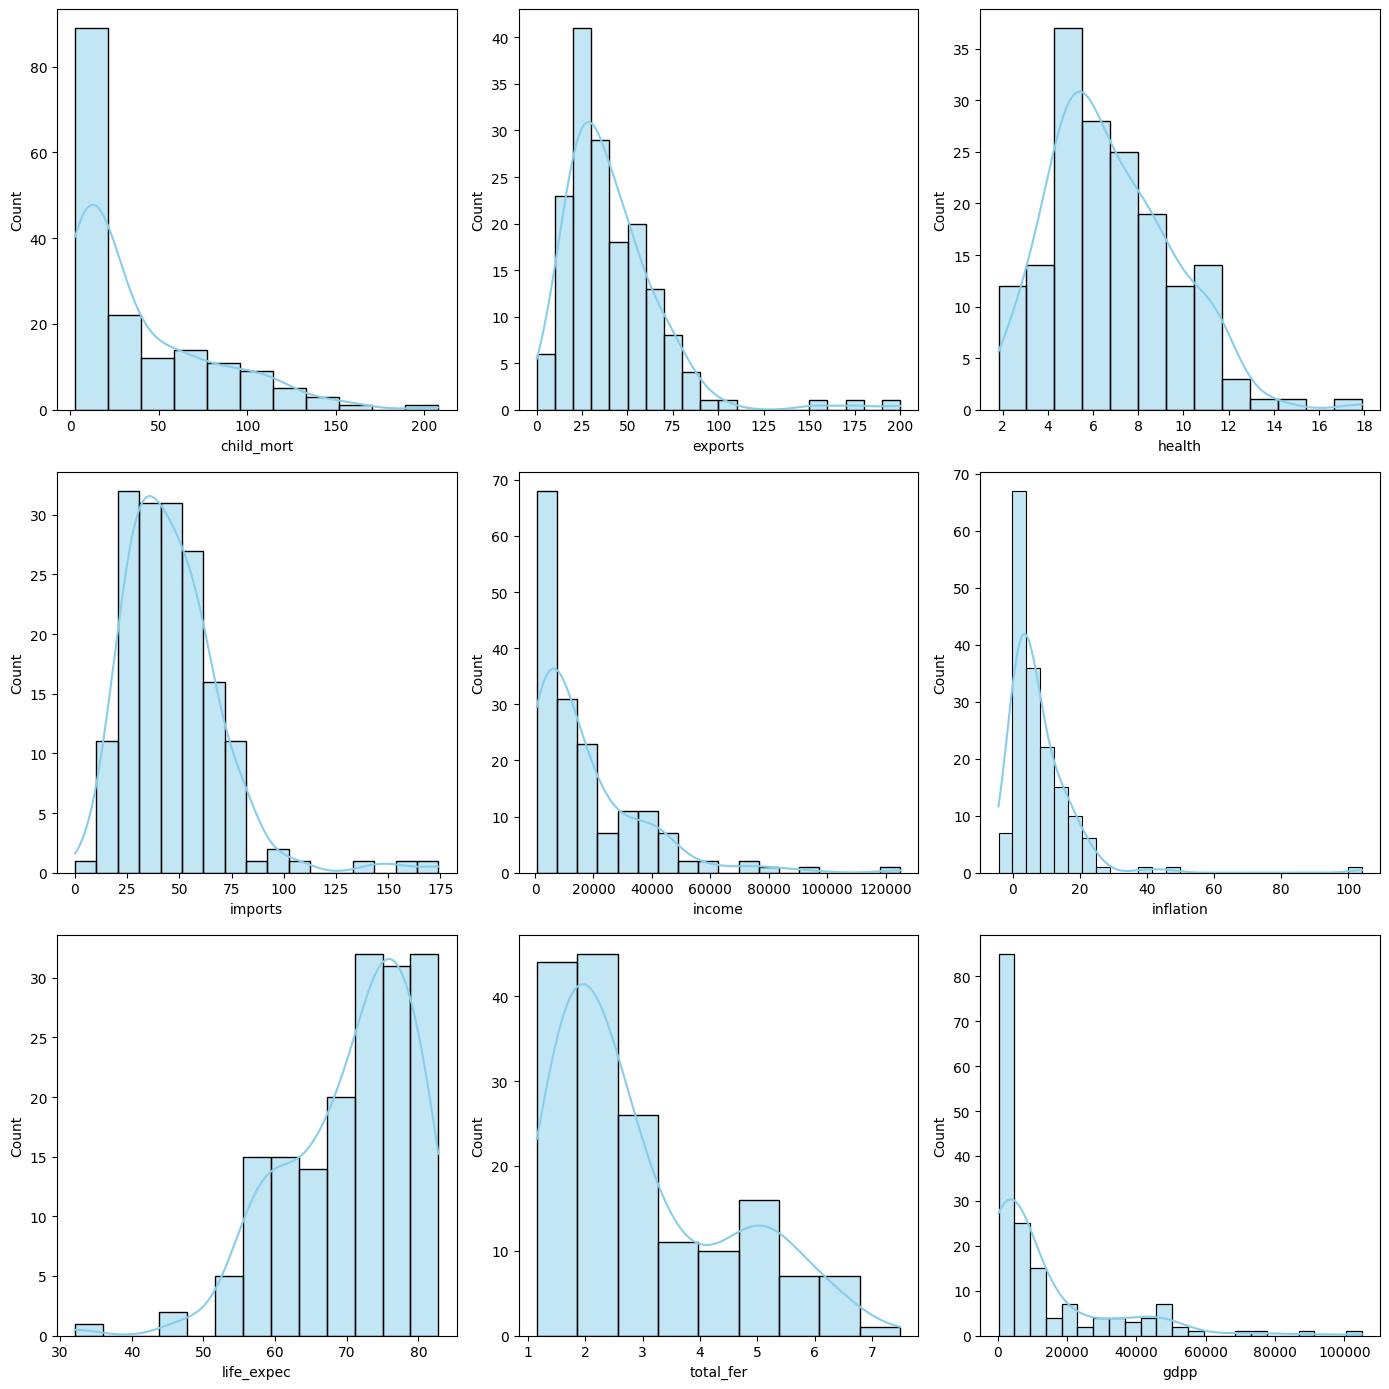

In [14]:
df_num = df.drop('country', axis=1)
plot_distributions(df_num, "images/distributions.png")

### Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer

ss = StandardScaler()
X_std = ss.fit_transform(df_num)
df_std = pd.DataFrame(X_std, columns=df_num.columns)
plot_distributions(df_std, "images/distributions_std.png")

pt = PowerTransformer()
X_pt = pt.fit_transform(df_num)
df_pt = pd.DataFrame(X_pt, columns=df_num.columns)
plot_distributions(df_pt, "images/distributions_pt.png")

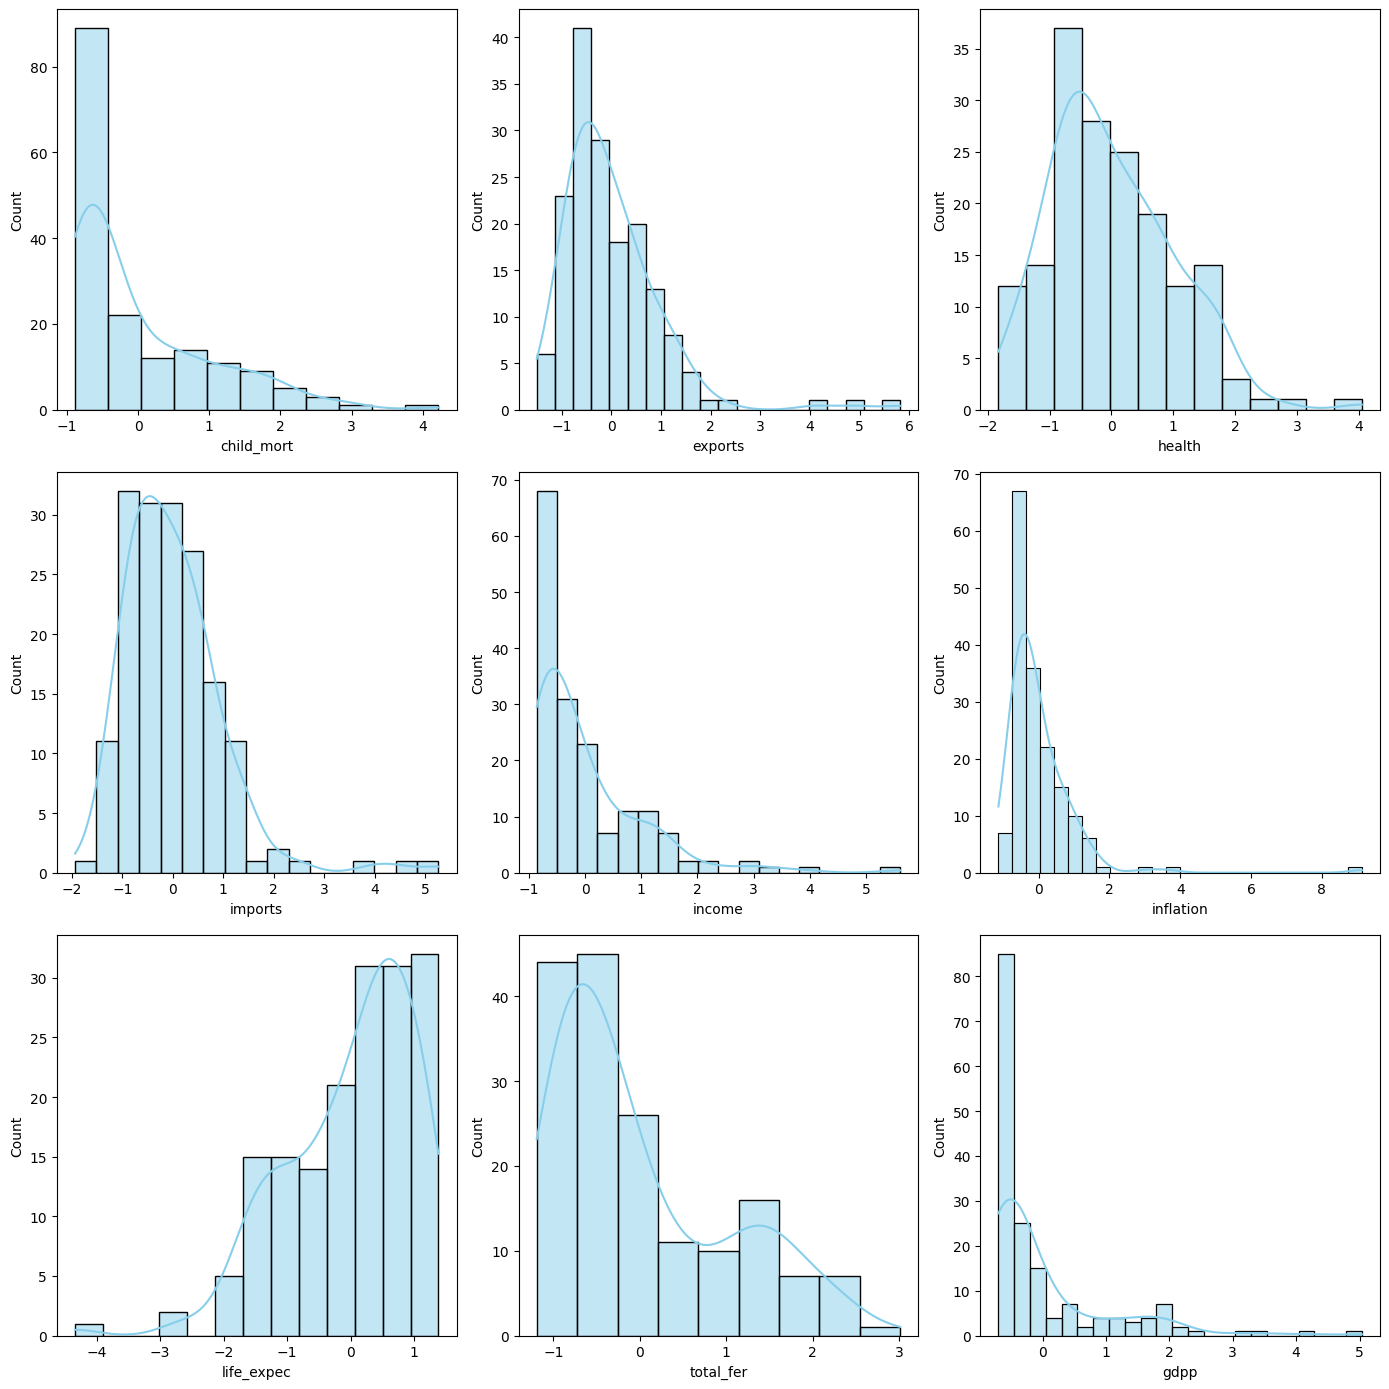

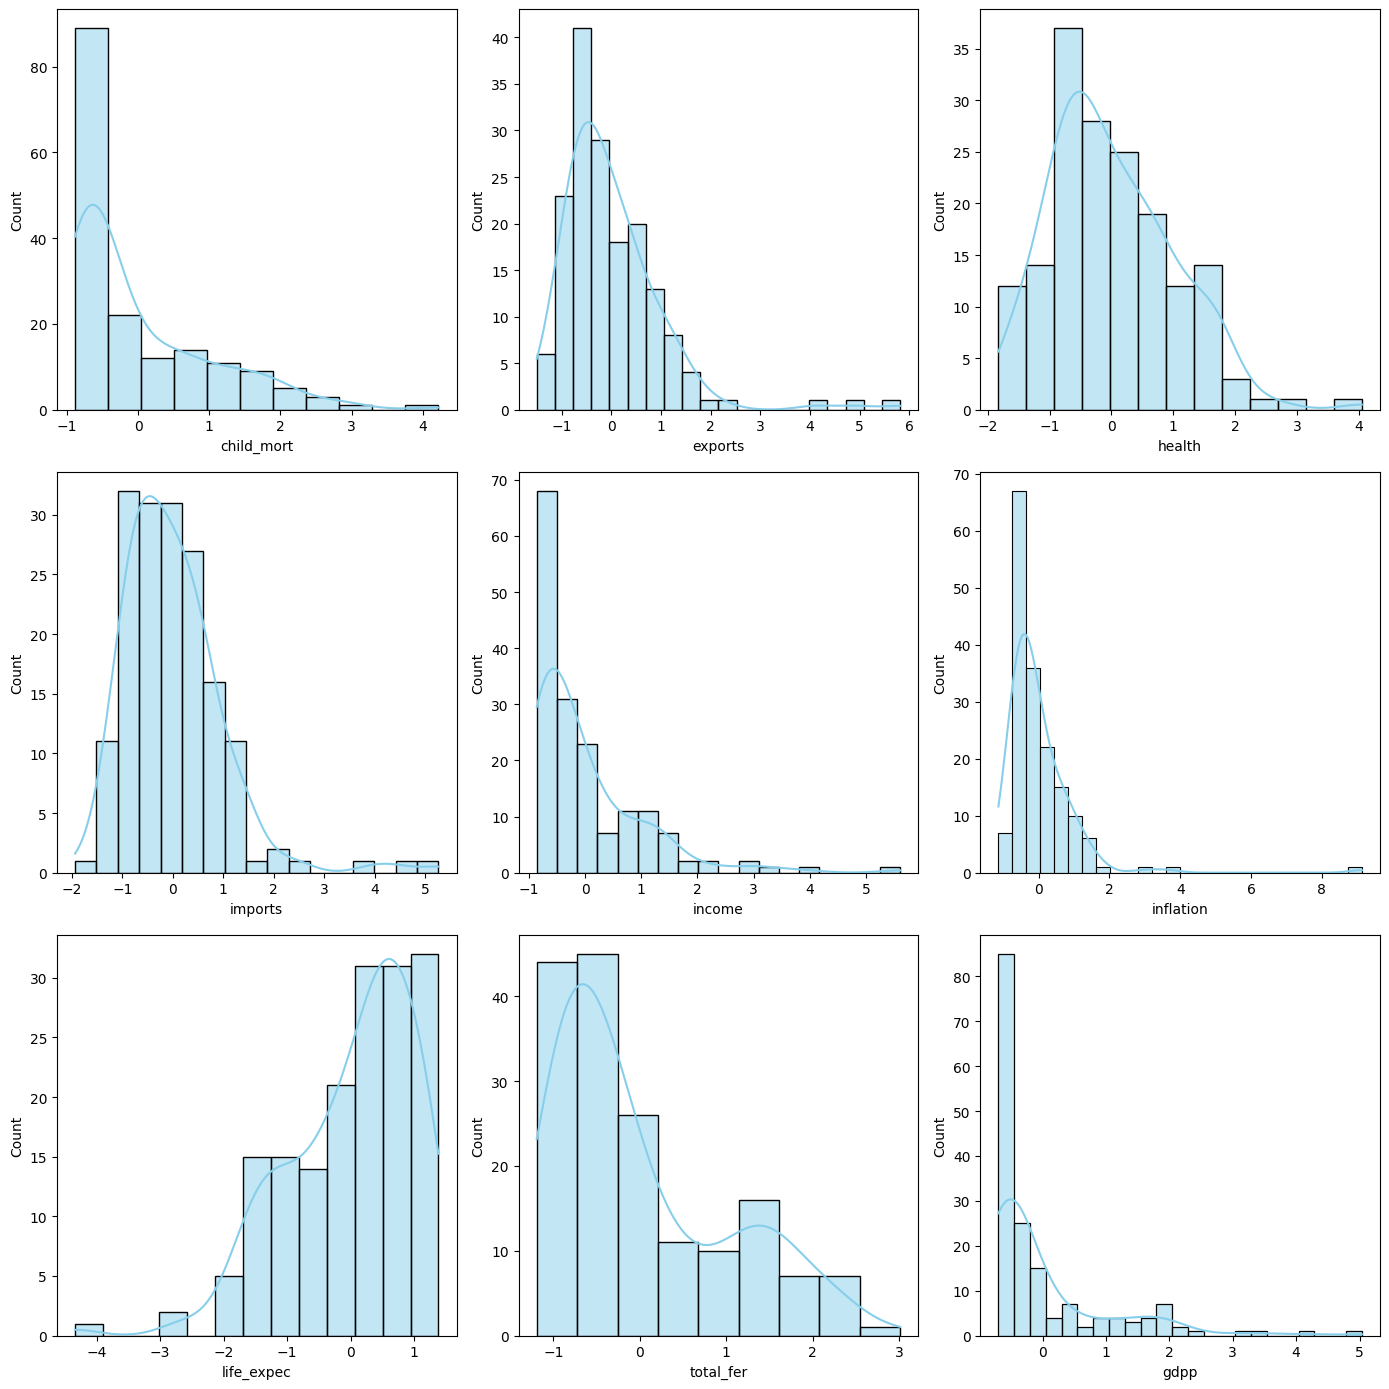

In [ ]:
strategies = {
    "": df_std, 
    "": df_pt, 
}

## Clustering Analysis

## Bayesian Network